In [1]:
import pandas as pd

df = pd.read_csv("cleaned_solar_data.csv")

df.head()

,bat_current,bat_status,bat_volt,load_current,load_status,load_volt,pv_current,pv_volt,ft,hour,minute
0,5.70,1,26.3,4.28,1,32.7,0.0,0.0,0,0,2
1,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
2,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
3,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2
4,5.59,1,26.8,4.19,1,33.4,0.0,0.0,0,0,2


In [2]:
X = df[['bat_current',
        'bat_volt',
        'pv_current',
        'pv_volt']]

In [3]:
from sklearn.ensemble import IsolationForest

In [4]:
model = IsolationForest(contamination=0.05)

In [5]:
df['anomaly'] = model.fit_predict(X)

In [6]:
df['anomaly'].value_counts()

anomaly
 1    152
-1      8
Name: count, dtype: int64

In [7]:
anomalies = df[df['anomaly'] == -1]

anomalies

,bat_current,bat_status,bat_volt,load_current,load_status,load_volt,pv_current,pv_volt,ft,hour,minute,anomaly
6,0.00,2,12.2,2.85,1,34.0,0.00,0.0,0,0,10,-1
7,2.63,1,13.0,2.63,1,13.0,0.00,0.0,0,0,12,-1
154,5.68,1,26.4,4.19,1,33.4,0.00,5.9,0,5,41,-1
155,5.76,1,26.0,4.30,1,32.6,0.00,7.1,0,5,43,-1
156,11.51,0,14.0,2.56,0,0.0,2.70,34.8,0,7,59,-1
157,6.48,0,14.0,5.13,0,25.8,13.18,63.3,0,8,32,-1
158,0.00,0,12.1,4.10,1,12.1,1.00,16.4,0,8,56,-1
159,0.00,0,11.6,4.34,1,11.6,2.30,16.3,0,9,26,-1


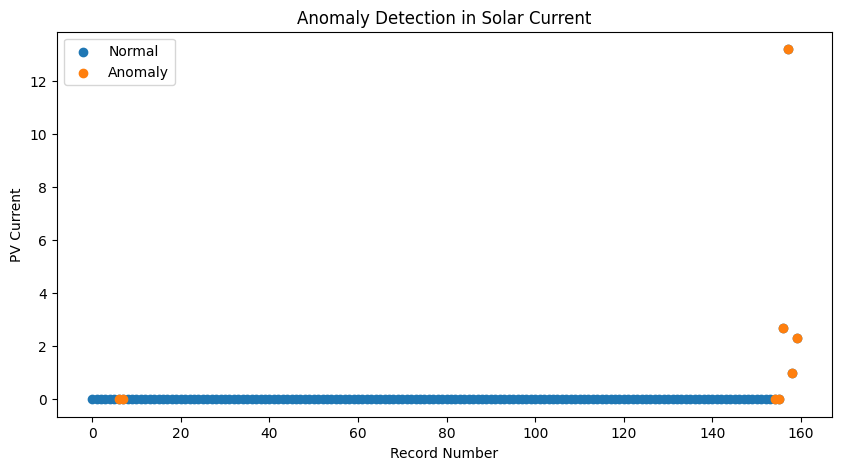

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(df.index,
            df['pv_current'],
            label='Normal')

plt.scatter(anomalies.index,
            anomalies['pv_current'],
            label='Anomaly')

plt.title("Anomaly Detection in Solar Current")

plt.xlabel("Record Number")
plt.ylabel("PV Current")

plt.legend()

plt.show()

In [9]:
anomalies.head()

,bat_current,bat_status,bat_volt,load_current,load_status,load_volt,pv_current,pv_volt,ft,hour,minute,anomaly
6,0.00,2,12.2,2.85,1,34.0,0.0,0.0,0,0,10,-1
7,2.63,1,13.0,2.63,1,13.0,0.0,0.0,0,0,12,-1
154,5.68,1,26.4,4.19,1,33.4,0.0,5.9,0,5,41,-1
155,5.76,1,26.0,4.30,1,32.6,0.0,7.1,0,5,43,-1
156,11.51,0,14.0,2.56,0,0.0,2.7,34.8,0,7,59,-1


In [10]:
df['anomaly'].value_counts()

anomaly
 1    152
-1      8
Name: count, dtype: int64

In [ ]:
#Isolation forest was used to detect unusual patterns in this dataset.
#this model identified 8 anomalies which indicates that it may have unusual battery conditions or any other solar generation abnormals etc.